# Ridge Regression

**Reduced Feature Set (PCA)**

Author: Pete King

We selected four models for this project, each of which approaches the regression problem of predicting future volatility differently.  The four models are:

 - Ridge Regressor:  A regressor that assumes all input features are independent and combine linearly; uses L2 norm regularization so that each input feature makes a nuanced contribution to the prediction.

 - Vector AutoRegressive Moving Average (VARMA):  An estimator that assumes input features are dependent on each other, but can be combined linearly to forecast the endogenous variable.

 - Gradient Boosting Regressor:  An decision tree based estimator that assumes all input features are independent, but makes no assumptions about linear relationships between exogenous variables.

 - Long Short-Term Memory (LSTM):  A deep-learning model that assumes input features are dependent on each other over time, but makes no assumptions about linear relationships between exogenous variables.

In this notebook, we test the ability of the Ridge regressor to predict future near-term volatility in a rolling outlook.

Here, each sample of financial data that we introduce to the estimator is a feature vector (**x_t**) that contains the daily return for the ETF, its near-term historical volatility, and other market and financial conditions at time **t**.  The label (**y_t**) for each sample is the mid-term future volatility, which we computed earlier using a rolling window.

Because the Ridge regressor assumes a linear relationship between exogenous variables, we need to to scale our features so that each falls in the range (0, 1).  Otherwise, large-magnitude features will tend to dominate the regression estimate.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)
from sklearn.linear_model import Lasso, Ridge, ElasticNet

import data_prep as dp

DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_etf_data.csv'
PCA_TRAIN_DATA_FILE = DATA_FOLDER + 'train_pca_data.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_etf_data.csv'
PCA_VAL_DATA_FILE = DATA_FOLDER + 'val_pca_data.csv'
TICKER = 'SPY'  # ETF selected for this analysis

## I. Import data

We have already split our data into training and validation sets.  We reserve the held-out validation set (val_df) to plot predictions for comparisons against other models, but we further divide the training set into cross-validation folds to take advantage of scikit-learn's [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) function.  This gives us an easy way to apply scikit-learn's standard cross-validation (CV) methods for hyperparameter optimization while preserving chronological order between training and validation subsets within CV folds.

In [2]:
# Combine PCA data with base data. From base data, select only historical 
# volatility and future volatility target.
train_df = dp.make_pca_df(TRAIN_DATA_FILE, PCA_TRAIN_DATA_FILE, TICKER)
val_df = dp.make_pca_df(VAL_DATA_FILE, PCA_VAL_DATA_FILE, TICKER)
train_df

,SPY_ret,SPY_h-vol,SPY_f-vol_target,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_macro-5,PCA_indicies-1,PCA_indicies-2,PCA_indicies-3,PCA_indicies-4
date,,,,,,,,,,,,,,
2015-10-22,0.016753,0.007990,0.008038,-0.060385,-0.049302,-0.045180,-0.042780,-0.051164,-0.030192,-0.027020,-0.035612,-0.031673,0.003920,-0.004416
2015-10-23,0.010902,0.008700,0.007682,-0.028761,-0.019623,-0.042593,-0.040932,-0.026452,-0.008330,-0.036960,-0.000326,-0.024071,-0.030029,-0.043408
2015-10-26,-0.002461,0.008729,0.007669,-0.038998,-0.035716,-0.048401,-0.050450,-0.037413,-0.043599,-0.024643,0.013070,-0.043886,-0.037661,-0.007188
2015-10-27,-0.001934,0.008519,0.007657,0.011014,0.006914,0.076367,0.080811,0.070985,-0.022329,-0.023923,-0.006781,-0.033949,-0.052711,-0.068107
2015-10-28,0.011310,0.009114,0.007253,-0.069678,-0.046203,-0.056724,-0.043523,-0.030986,0.005244,0.009962,0.023684,0.088783,0.087957,0.062373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-25,-0.000224,0.007469,0.012897,-0.143119,-0.147170,-0.158972,-0.164089,-0.165783,-0.205792,-0.082340,-0.054542,0.063587,0.081313,0.008595
2022-11-28,-0.016086,0.008508,0.012706,-0.009138,0.052201,0.074293,0.078177,0.077974,-0.028327,-0.015203,-0.033317,-0.047889,-0.073258,-0.059011
2022-11-29,-0.001719,0.008086,0.013284,-0.153767,-0.197632,-0.167729,-0.112797,-0.078021,-0.137523,-0.152878,-0.046367,-0.021137,0.021585,0.059925


In [3]:
val_df

,SPY_ret,SPY_h-vol,SPY_f-vol_target,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_macro-5,PCA_indicies-1,PCA_indicies-2,PCA_indicies-3,PCA_indicies-4
date,,,,,,,,,,,,,,
2023-01-03,-0.004219,0.010242,0.011025,0.453110,0.416835,0.381414,0.326702,0.354621,0.360311,0.337204,0.291585,0.291259,0.358576,0.305696
2023-01-04,0.007691,0.010177,0.011143,0.317675,0.311223,0.310984,0.294959,0.261770,0.240383,0.213406,0.250842,0.217873,0.185065,0.198466
2023-01-05,-0.011479,0.010796,0.010940,0.206405,0.258067,0.235417,0.230884,0.254676,0.296916,0.303690,0.282478,0.260471,0.297770,0.289716
2023-01-06,0.022673,0.012081,0.010161,0.382678,0.367219,0.349151,0.388915,0.363785,0.384096,0.367638,0.377479,0.353326,0.390000,0.430783
2023-01-09,-0.000567,0.011195,0.010439,0.401736,0.431695,0.521250,0.756041,0.699941,0.724333,0.684553,0.786744,0.791241,0.633941,0.517984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-26,-0.002387,0.009243,0.008510,0.329960,0.387138,0.362461,0.330073,0.330884,0.296511,0.139929,0.181070,0.182610,0.201420,0.195621
2024-08-27,0.001372,0.007682,0.008549,0.152327,0.150704,0.200752,0.162793,0.159418,0.108765,0.115386,0.132175,0.131496,0.134801,0.185632
2024-08-28,-0.005822,0.007836,0.008460,0.137624,0.144313,0.192165,0.154747,0.155202,0.120963,0.152945,0.166141,0.151012,0.094235,0.129049


In [4]:
# Separate features from labels
data_cols, _ = dp.get_X_y_cols(train_df, returns=True)
label_col = [TICKER + '_f-vol_target']
# Training set
X_train = train_df.dropna()[data_cols].astype(np.float32)
y_train = train_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Validation set
X_val = val_df.dropna()[data_cols].astype(np.float32)
y_val = val_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Define time series cross-validation split
ts_cv = TimeSeriesSplit(
    n_splits=3,
    test_size=252,
    gap=21
)
# Scale input features
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=data_cols
)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=data_cols)

## II. Define model, fit to data, and evaluate performance

Here we tune the amount of 

In [5]:
# Define model, metrics, and Grid Search for hyperparameter tuning
estimator = Ridge()
metrics = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MSE': 'neg_mean_squared_error',
    'r2': 'r2'
}
params = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 0.5, 1]
}
reg = GridSearchCV(
    estimator,
    params,
    scoring=metrics,
    refit='MAE',
    cv=ts_cv
)

In [6]:
reg.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error', 'RMSE': 'neg_root_mean_squared_error', 'r2': 'r2'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'MAE'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...test_size=252)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

### Visualize performance; Check evaluation metrics

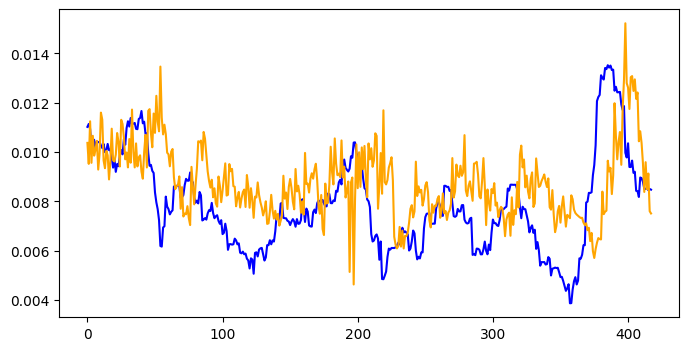

In [7]:
# Use the best estimator to make predictions on the validation set
best = reg.best_estimator_
preds = best.predict(X_val_scaled)
x = range(len(y_val))

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()

ax.plot(x, y_val, color='blue')
ax.plot(x, preds, color='orange')

In [8]:
print(f'MAE: {mean_absolute_error(y_val, preds)}')
print(f'R2: {r2_score(y_val, preds)}')

MAE: 0.0017745723016560078
R2: -0.29354119300842285


From the plot we see that the model tends to follow the general future volatility trend fairly well, although its predictions tend to lag true historical volatility.  Surprisingly, the resulting predictions appear to be much noisier than the predictions from the Ridge model using the full feature set.

## III. Inspect model

Since we scaled all input features in the range (0, 1), we can look at the coefficients assigned to each feature to understand which ones are assigned the most weight (greatest coefficients) in the regression.

In [9]:
feature_importances = list(zip(best.feature_names_in_, best.coef_))
for feature, coef in sorted(feature_importances, key=lambda i: -np.abs(i[1])):
    print(f'{feature}: {coef:2.3f}')

SPY_h-vol: 0.038
PCA_macro-3: -0.019
SPY_ret: -0.014
PCA_macro-4: 0.013
PCA_macro-2: 0.007
PCA_indicies-4: -0.006
PCA_macro-5: 0.005
PCA_indicies-2: -0.004
PCA_indicies-3: 0.004
PCA_vol-2: -0.003
PCA_indicies-1: -0.002
PCA_vol-1: 0.001
PCA_macro-1: 0.000


Here we see that historical volatility for the asset we are trying to predict is clearly the most important feature, althoug return and macroeconomic factors are also important.  The low ranking for the volatility indicies is surprising, especially how low the first principal component of the volatility indicies (PCA_vol-1) ranked in importance.